# Steering Word Embeddings

## What are Word Embeddings?

A dictionary explains a word using other words — a human-readable representation. A word embedding explains a word using a list of numbers — a machine-readable representation. Rather than hand-coding these numbers, we learn them from data, so that words with similar meanings end up with similar numbers.

The learning principle behind word embeddings is the *distributional hypothesis*: a word's meaning can be inferred from the words it co-occurs with.  Thus, to learn embeddings, we start with a text corpus and construct a **word co-occurrence matrix**, counting how often pairs of words co-occur within a given window.

<img src="figs/word-co-occurrence.png" alt="Word co-occurrence matrix" style="width: 600px;"/>
<p style="font-size:9pt"><a href="http://web.stanford.edu/class/cs224u/materials/cs224u-vsm-overview.pdf">source</a></p>

Each row is a sparse, high-dimensional representation of a word. Words in similar contexts get similar rows, so there is some notion of similarity here, but the raw counts don't have much useful geometric structure — you can't do analogies on them, for example (more on analogies below).

Methods like [word2vec](https://arxiv.org/abs/1301.3781) and [GloVe](https://nlp.stanford.edu/projects/glove/) don't just compress the co-occurrence matrix. They learn low-dimensional vectors with approximately linear structure — the reason analogies work and the subspace methods in this notebook are possible.

In this notebook, we use 100-dimensional GloVe vectors trained on 6 billion tokens of text.

## Setup

In [1]:
import numpy as np
from numpy.linalg import norm
from arsenal import Alphabet
from embedding import Embeddings, normalize_rows, load_vecs

In [2]:
with np.load('vecs.npz') as data:
    glove_vecs = data['vec']
    glove_ix = data['voc']

emb = Embeddings(normalize_rows(glove_vecs), Alphabet(glove_ix))
analogy = emb.analogy

## Structure in the Embedding Space

Do embeddings capture meaningful structure? We can check by visualizing groups of related words.

Since our vectors are 100-dimensional, we need to project them to 2D for plotting. We use **[MDS (multidimensional scaling)](https://en.wikipedia.org/wiki/Multidimensional_scaling)**, which finds a 2D layout that best preserves the pairwise distances between words in the original space. Some distortion is inevitable when collapsing 100 dimensions to 2, but the main patterns come through.

**Superlatives** — adjective forms trace out parallel paths:

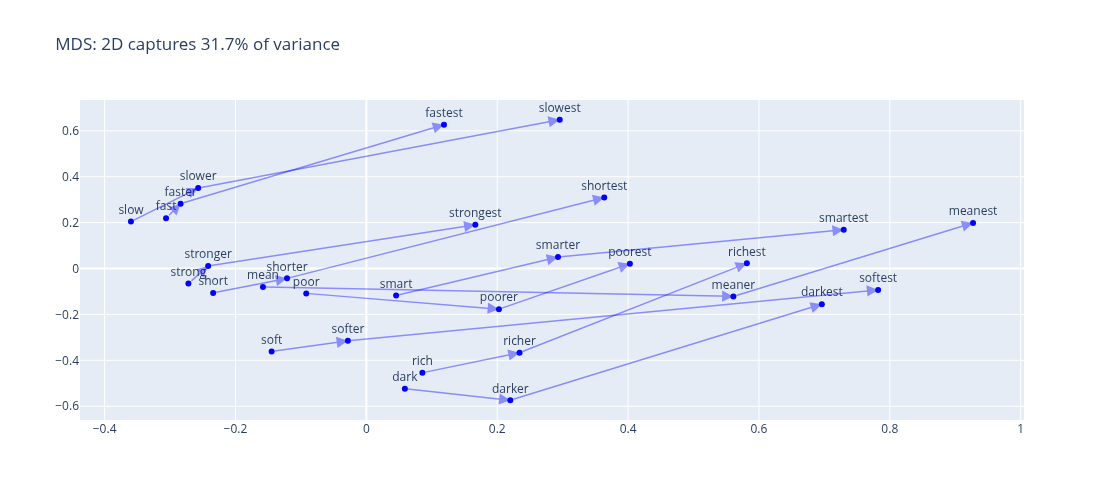

In [3]:
superlatives = """
poor   poorer   poorest
rich   richer   richest
short  shorter  shortest
slow   slower   slowest
fast   faster   fastest
soft   softer   softest
strong stronger strongest
mean   meaner   meanest
dark   darker   darkest
smart  smarter  smartest
"""

emb.plot_paths(superlatives)

**Numbers** — digits and their word forms occupy distinct but parallel subspaces:

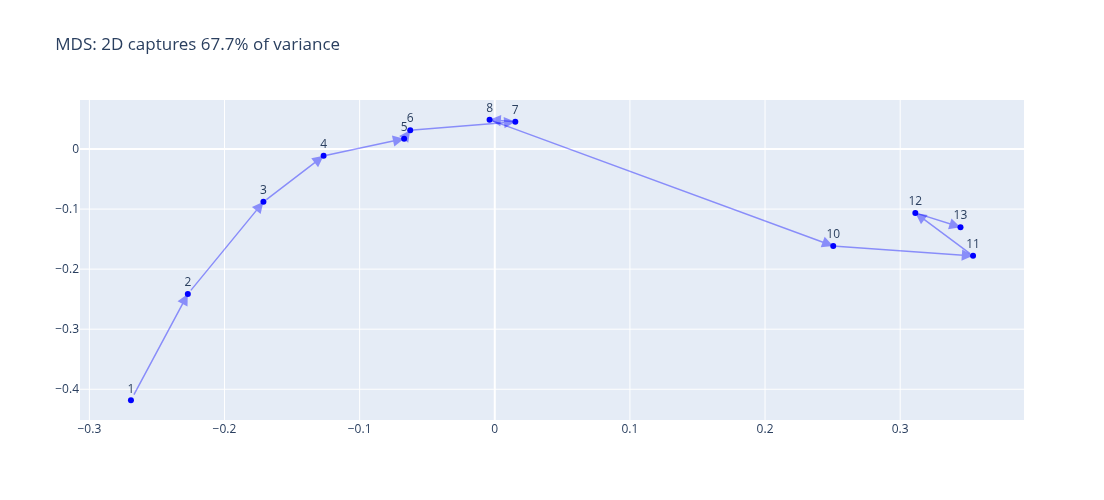

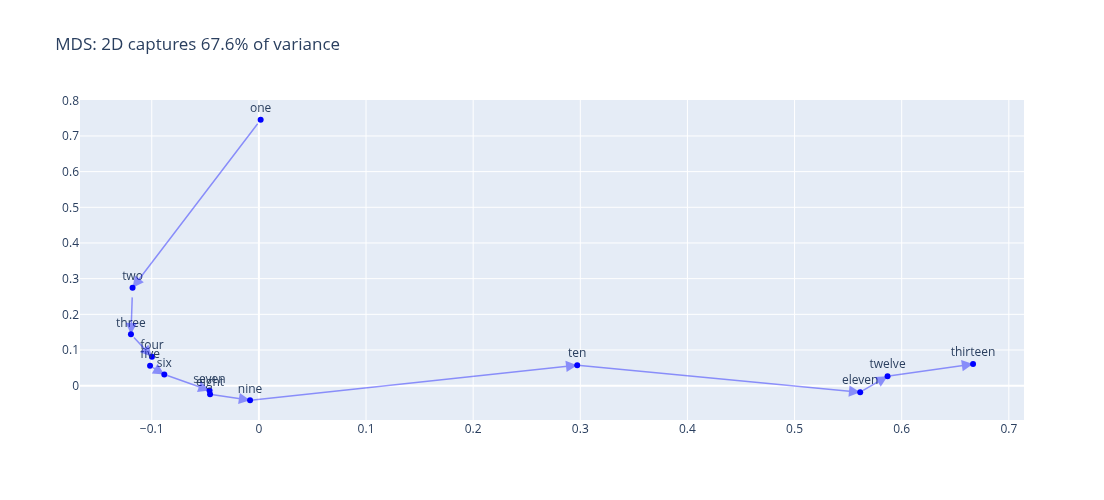

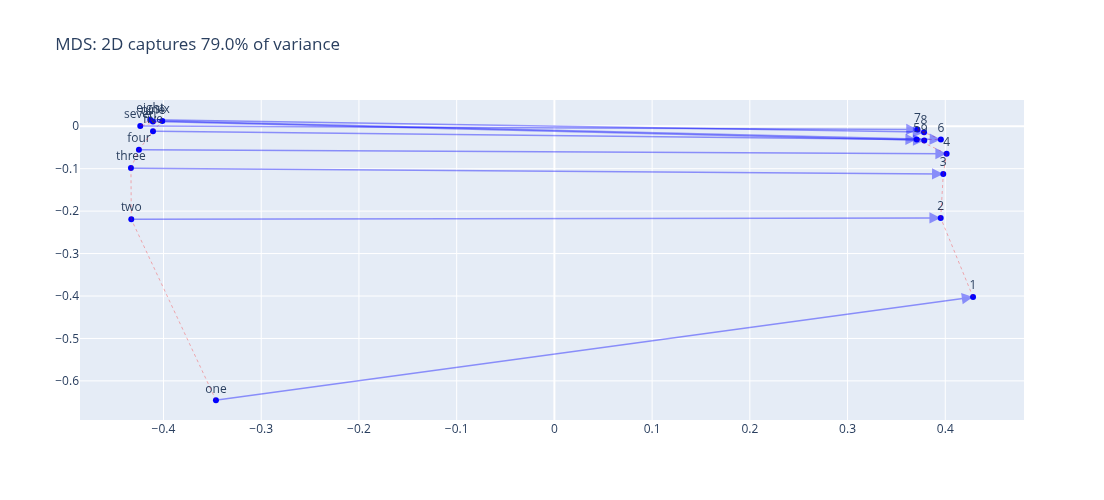

In [4]:
emb.plot_paths("""
1 2 3 4 5 6 7 8 10 11 12 13
""")

emb.plot_paths("""
one two three four five six seven eight nine ten eleven twelve thirteen
""")

emb.plot_paths("""
one 1
two 2
three 3
four 4
five 5
six 6
seven 7
eight 8
nine 9
""", connect_groups=True)

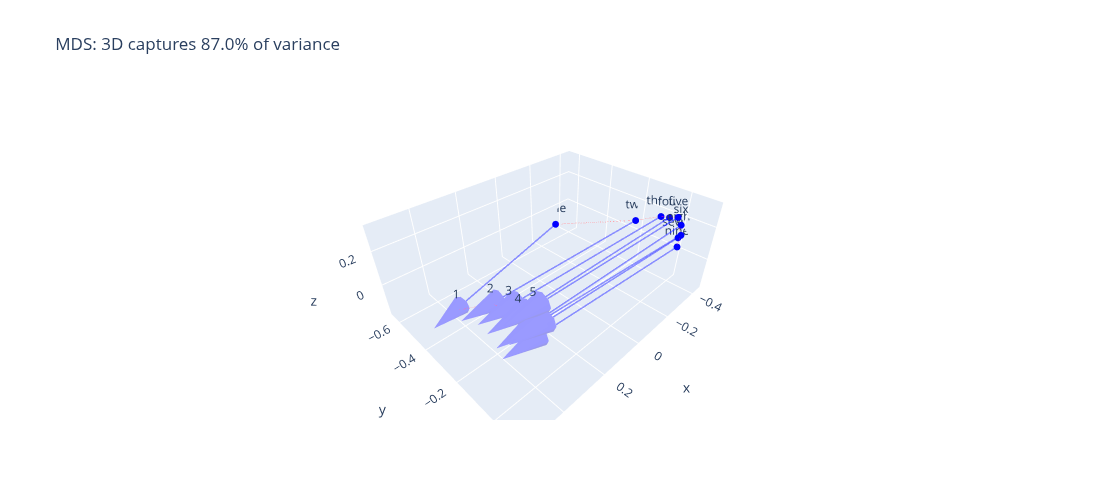

In [5]:
emb.plot_paths("""
one 1
two 2
three 3
four 4
five 5
six 6
seven 7
eight 8
nine 9
""", connect_groups=True, dimensions=3)

The plot of 1--13 above shows some curvature. Is that real structure in the 100D embeddings, or just an artifact of projecting to 2D?

MDS finds the 2D layout that best preserves pairwise distances. If the numbers lay on a line in 100D, MDS would show a line. We can check by looking at the eigenvalues from MDS — they tell us how much variance each dimension captures. If the top 2 dominate, the 2D projection is faithful and the curvature is real:

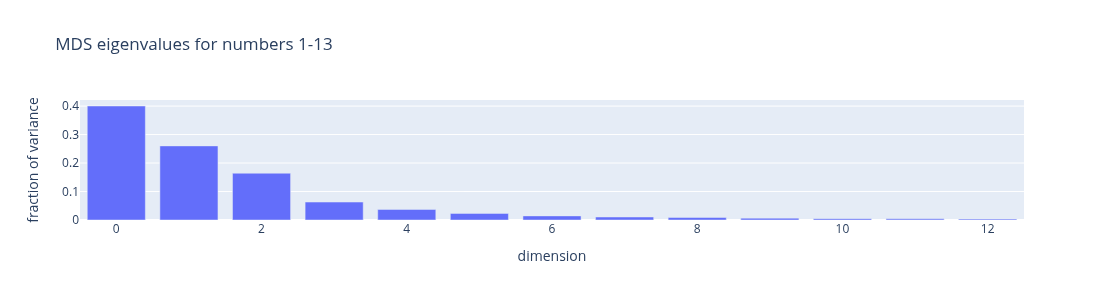

Top 2 dimensions capture 66.0% of the variance


In [6]:
from embedding import mds
import plotly.graph_objects as go

numbers = [str(i) for i in range(1, 14)]
D = emb.distance_matrix(numbers)
Y, S = mds(D)

fig = go.Figure(go.Bar(x=list(range(len(S))), y=S / S.sum()))
fig.update_layout(xaxis_title='dimension', yaxis_title='fraction of variance',
                  title='MDS eigenvalues for numbers 1-13', width=600, height=300)
fig.show()
print(f'Top 2 dimensions capture {S[:2].sum()/S.sum():.1%} of the variance')

We can also look at the 3D MDS projection to see if the extra dimension reveals structure that was distorted in 2D:

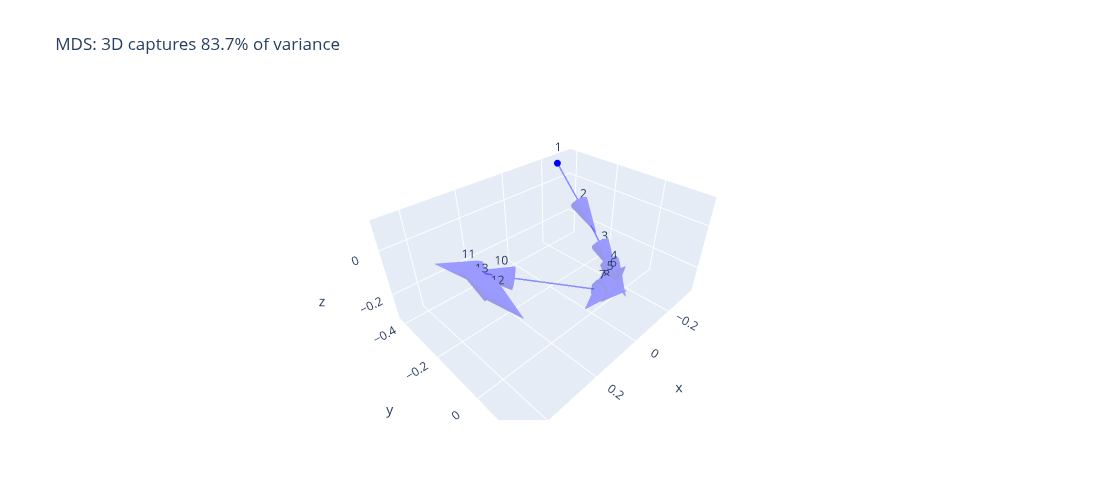

In [7]:
emb.plot_paths("""
1 2 3 4 5 6 7 8 10 11 12 13
""", dimensions=3)

## Word Analogies

These regularities give rise to **word analogies**. The vector difference between related word pairs is roughly constant:

$$\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$$

More generally, if $w_1 : w_2 :: w_3 : w_4$, then $w_4 \approx w_2 - w_1 + w_3$.

The red arrows below show how the offset from "man" to "woman" is roughly parallel to the offset from "king" to "queen":

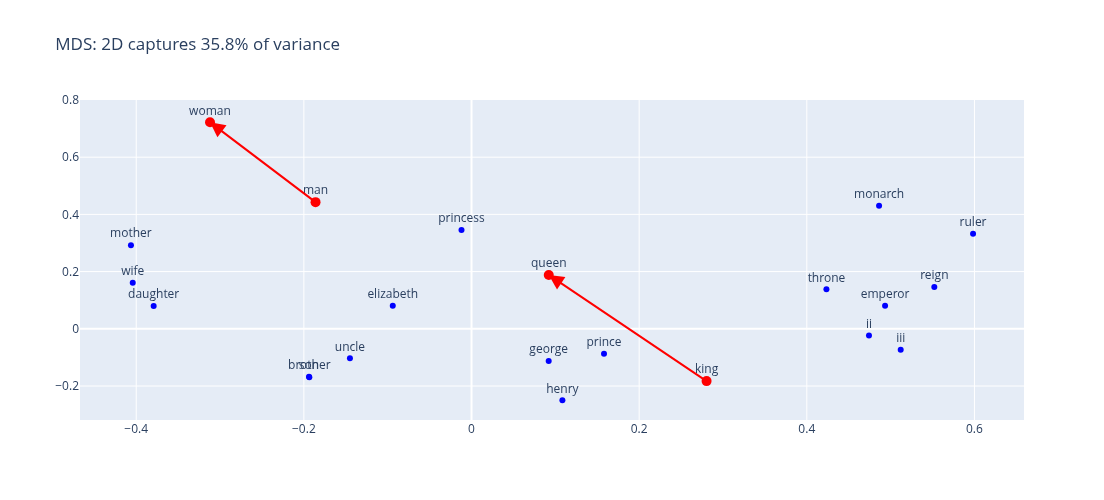

In [9]:
emb.plot_analogy('man', 'woman', 'king', n=10)

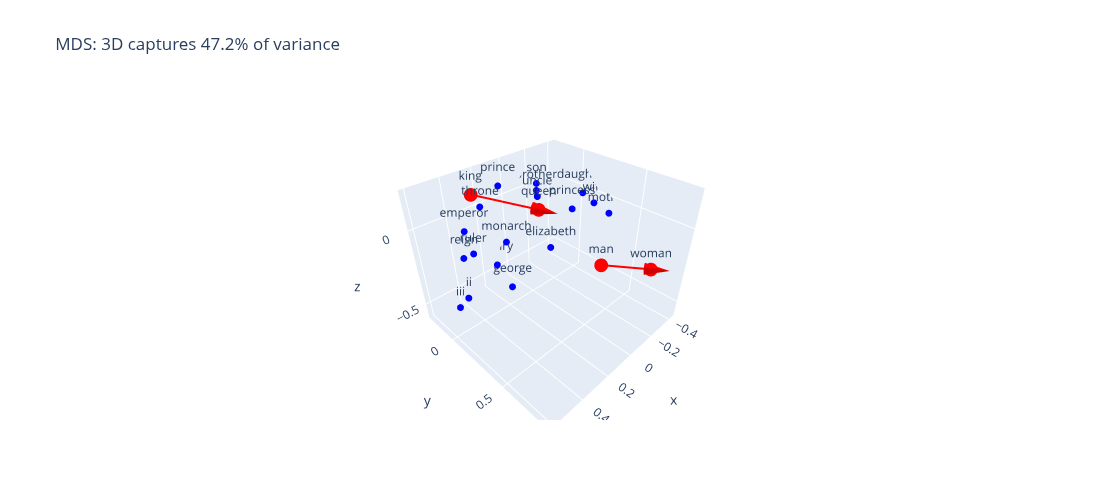

In [10]:
emb.plot_analogy('man', 'woman', 'king', n=10, dimensions=3)

This works across many types of relationships:

In [11]:
analogy("man :: king -> woman")
analogy("man :: prince -> woman")
analogy("man :: boy -> woman")
analogy("man :: dad -> woman")
analogy("man :: uncle -> woman")
analogy("man :: fraternity -> woman")

man :: king -> woman :: [queen]
man :: prince -> woman :: [princess]
man :: boy -> woman :: [girl]
man :: dad -> woman :: [mom]
man :: uncle -> woman :: [aunt]
man :: fraternity -> woman :: [sorority]


## Identifying Subspaces

The analogy examples hint at something deeper: the embedding space contains **interpretable subspaces**. The "gender direction" isn't just a pattern between a few word pairs — it's a consistent axis along which many words vary.

We can identify these subspaces systematically. Given groups of word pairs that vary along some concept, we compute the covariance of their embeddings and extract the top-$k$ singular vectors. This gives us an orthogonal basis $\mathcal{B} = \{b_1, \dots, b_k\}$ for the subspace that best explains the variation within those groups.

## Steering by Subspace Projection

Once we have a subspace, we can **steer** the embeddings by projecting it out:

$$\vec{w}_{\text{steered}} = \frac{\vec{w} - \vec{w}_{\mathcal{B}}}{\|\vec{w} - \vec{w}_{\mathcal{B}}\|} \quad \text{where} \quad \vec{w}_{\mathcal{B}} = \sum_{j=1}^{k} (\vec{w} \cdot \vec{b}_j) \, \vec{b}_j$$

This removes each word's component along the chosen subspace while preserving everything else. The result is a new embedding space where that concept has been neutralized.

Let's try this with gender. We define the subspace using pronoun pairs that differ only in gender:

In [10]:
gender_pairs = """
she he
woman man
herself himself
her him
hers his
gal guy
girl boy
girls boys
female male
females males
"""

steered = emb.debias(gender_pairs, K=10)

The words most affected are those with the strongest component along the gender subspace:

In [11]:
diff = norm(emb.vec - steered.vec, axis=1)
top = np.argsort(-diff)
for i in top[:10]:
    w = emb.dom.lookup(i)
    print(f'{diff[i]:.3f}  {w}')

0.779  menstruating
0.746  defensive
0.725  fantastic
0.719  kiddin
0.719  george
0.715  gal
0.715  guy
0.712  toretta
0.712  twaron
0.706  everyplace


## Results

### Analogies: Before vs. After

In the original embeddings, "man :: woman -> doctor" yields "nurse" — the gender subspace dominates the analogy. After steering, both directions yield "physician":

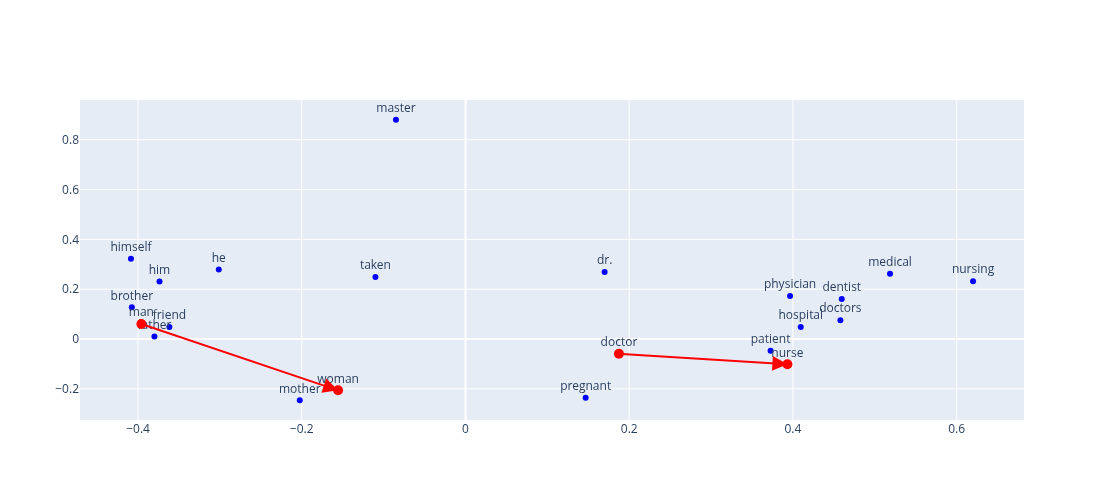

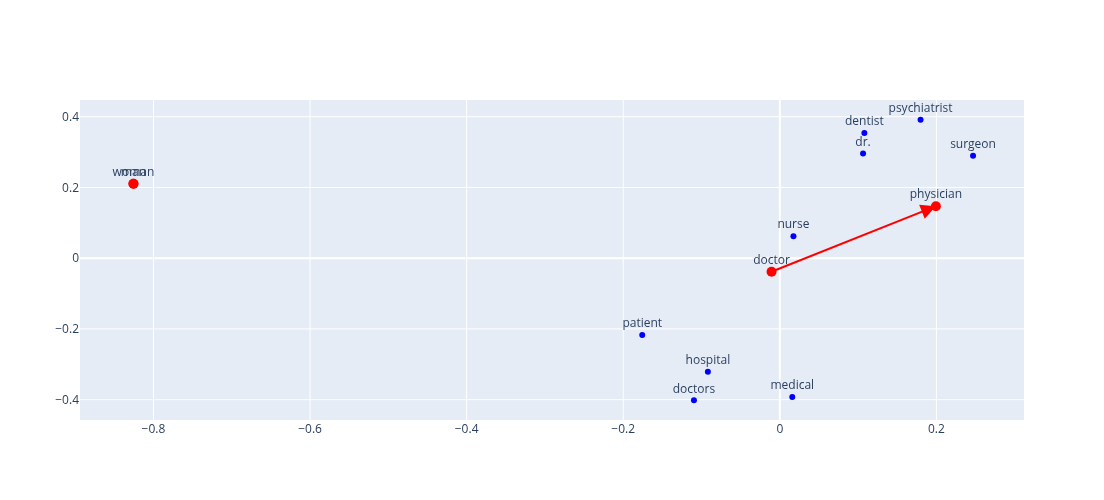

In [12]:
emb.plot_analogy('man', 'woman', 'doctor', n=10)
steered.plot_analogy('man', 'woman', 'doctor', n=10)

In [13]:
steered.analogy("man :: woman -> doctor")
steered.analogy("woman :: man -> doctor")

man :: woman -> doctor :: [physician]
woman :: man -> doctor :: [physician]


Similarly for "programmer":

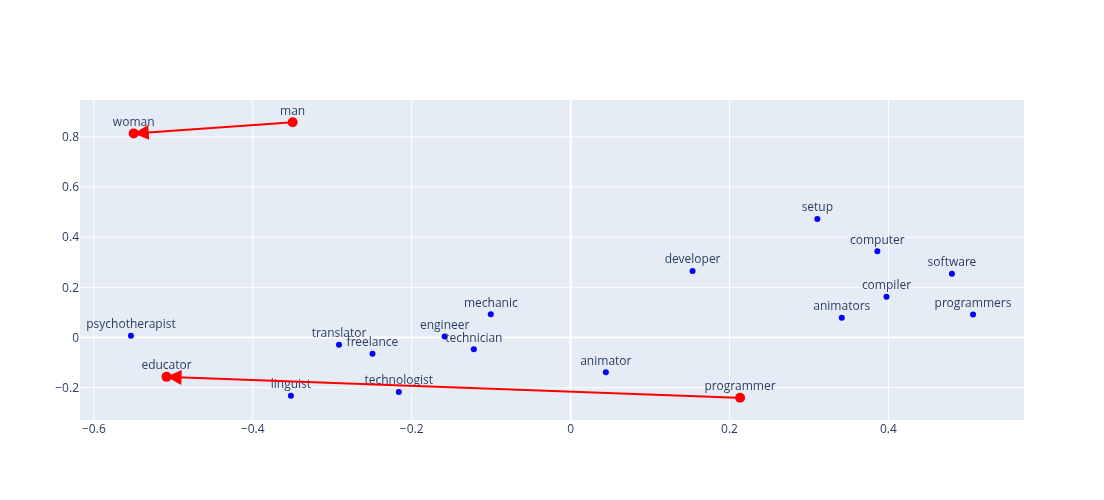

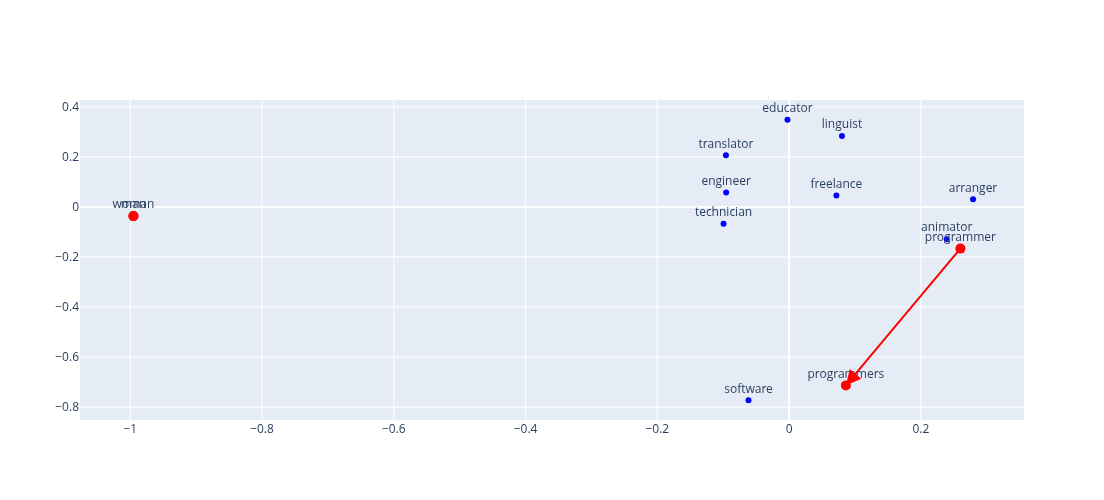

In [14]:
emb.plot_analogy('man', 'woman', 'programmer', n=10)
steered.plot_analogy('man', 'woman', 'programmer', n=10)

In [15]:
steered.analogy("man :: woman -> programmer")
steered.analogy("woman :: man -> programmer")

man :: woman -> programmer :: [programmers]
woman :: man -> programmer :: [programmers]


### Visualization: Before vs. After

The MDS plots show how steering collapses variation along the gender direction. In the original embeddings, male-female pairs spread apart along a consistent axis. After steering, the pairs cluster tightly:

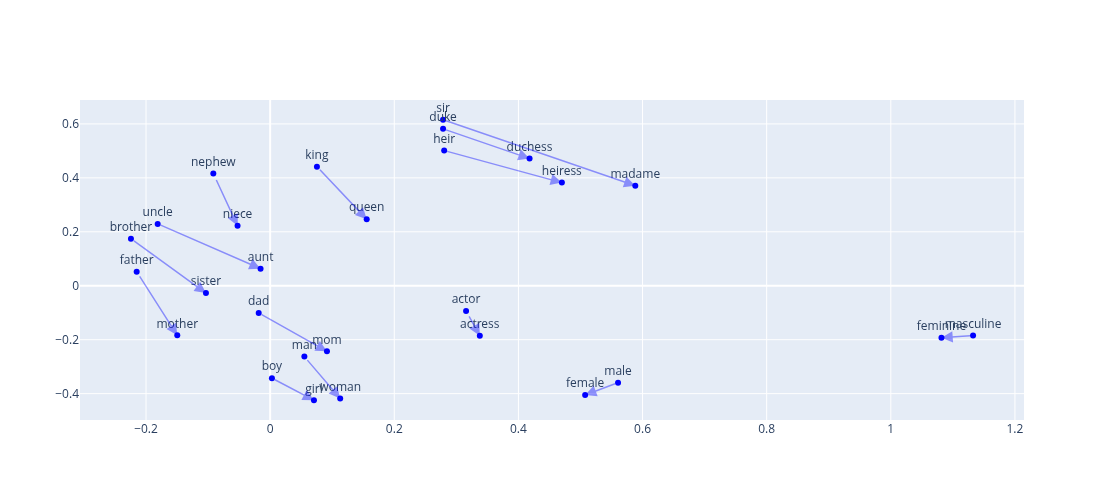

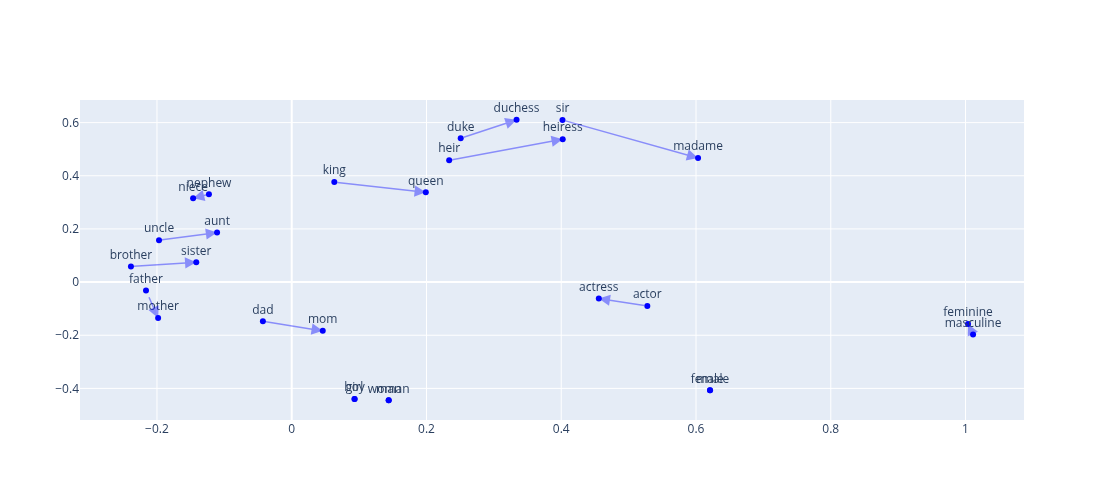

In [16]:
gendered = """
man   woman
king  queen
actor actress
boy   girl
dad   mom
father mother
brother sister
uncle aunt
heir heiress
duke duchess
nephew niece
sir madame
male female
masculine feminine
"""

emb.plot_paths(gendered)
steered.plot_paths(gendered)

### Which Words Changed Most?

We can rank words by how far their embedding moved. Larger shifts mean a stronger component along the gender subspace:

In [17]:
professions = [
    'caretaker', 'homemaker', 'doctor', 'nurse', 'programmer', 'teacher',
    'wife', 'husband', 'soldier', 'salesperson', 'analyst', 'therapist',
    'trainer', 'instructor', 'ceo', 'assistant', 'telemarketer',
    'bartender', 'clerk', 'designer', 'father', 'mother', 'scientist',
    'manager', 'boss', 'self-employed', 'employee',
]

sorted(professions, key=lambda w: -norm(steered(w) - emb(w)))

['manager',
 'mother',
 'assistant',
 'boss',
 'father',
 'wife',
 'designer',
 'husband',
 'bartender',
 'trainer',
 'nurse',
 'clerk',
 'homemaker',
 'self-employed',
 'doctor',
 'soldier',
 'therapist',
 'salesperson',
 'telemarketer',
 'caretaker',
 'ceo',
 'programmer',
 'teacher',
 'scientist',
 'analyst',
 'instructor',
 'employee']

Arrows show the direction and magnitude of the steering correction for each word:

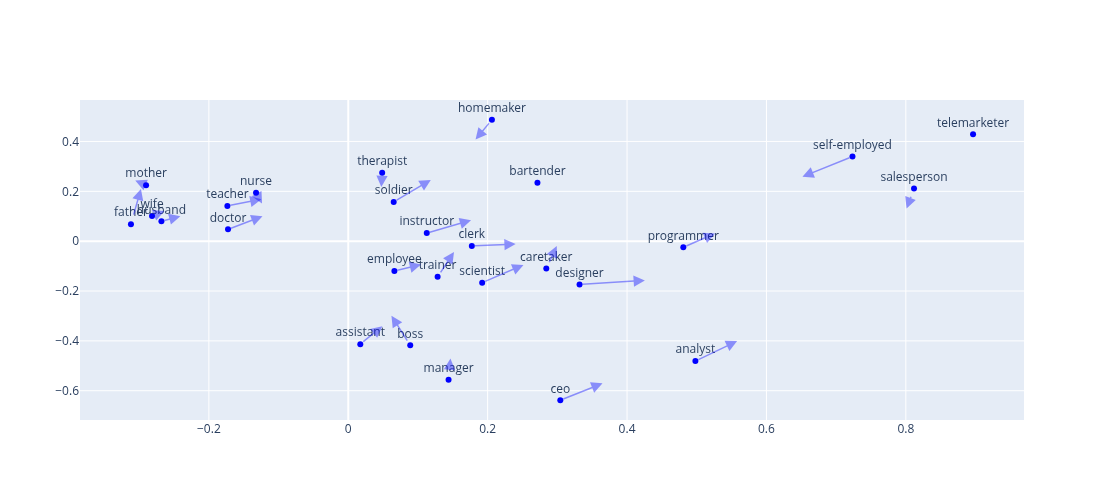

In [18]:
from embedding import plot_change
plot_change(professions, emb, steered)